In [8]:
from transformers import AutoModelForMaskedLM
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, AutoModelForSeq2SeqLM, AutoConfig
import torch
device = torch.device('cuda:1')

tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
config = AutoConfig.from_pretrained('facebook/esm2_t6_8M_UR50D')
model = AutoModelForMaskedLM.from_pretrained('facebook/esm2_t6_8M_UR50D').to(device)
model.eval()
print("Loaded BERT Model")

Loaded BERT Model


In [9]:
import pandas as pd
enzyme_df= pd.read_csv('../../data/enzyme_dataset_seq.csv')
enzyme_df= enzyme_df[~enzyme_df['Sequence'].isna()]
enzyme_go_terms = [gt.split("'")[1] for gt in enzyme_df['GOTerm']]
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
enzyme_df['GOTerm'] = enzyme_go_terms
enzyme_df= enzyme_df[enzyme_df['GOTerm'].isin(term_ind_map)]
enzyme_term_index = [term_ind_map[t] for t in enzyme_df['GOTerm']]
enzyme_df['GOTermIndex'] = enzyme_term_index
annotated_indices = [list(filter(lambda x: x < min(1024, len(seq)), map(int, x[1:-1].split(',')))) for x, seq in zip(enzyme_df['AnnotatedIndices'], enzyme_df['Sequence'])]
enzyme_df['AnnotatedIndices'] = annotated_indices

import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
def enzyme_iterator():
     for i, pid, annot_ind, enzyme_cls, goterm, seq, go_ind in enzyme_df.itertuples():
          # print(pid, annot_ind, enzyme_cls, goterm, seq, go_ind)
          inputs = tokenizer.batch_encode_plus([seq], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
          yield {'prot_id': pid, 'annot_ind': annot_ind, 'go_ind': go_ind, 'seq': seq, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask']}

In [1]:
r = next(iter(enzyme_iterator()))
bert_attribution_l = []
with torch.no_grad():
    seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
    residue_coverage = 6
    seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :], mask[:, :], tokenizer.mask_token_id, residue_coverage=residue_coverage)
    bert_pred = model(seq_batch, torch.tile(mask, (seq_batch.shape[0], 1)))
    mut_distr = torch.softmax(bert_pred.logits, dim=2)
    N, L, T = bert_pred.logits.shape
    bert_distr = torch.zeros(L, T, device=device)
    for bi, ti in zip(batch_inds.flatten(), mut_inds.flatten()):
        bert_distr[ti, :] += mut_distr[bi, ti, :]
    bert_distr /= residue_coverage
bert_distr = bert_distr.cpu()

NameError: name 'enzyme_iterator' is not defined

In [10]:
def mask_seq(seq_ind, attention_mask, mask_token, residue_coverage=6, mut_per=0.15):
    device = seq_ind.device
    seq_len = attention_mask.sum()-1
    mut_count = torch.floor(seq_len*mut_per).int().item()
    total_muts = (torch.floor(seq_len*residue_coverage/mut_count)*mut_count).int().item()

    mut_inds = (torch.randperm(total_muts).reshape(-1, mut_count).to(device) % seq_len) + 1
    batch_inds = torch.tile(torch.arange(0, mut_inds.shape[0]).reshape((-1, 1)), (1, mut_count))
    mut_inds, batch_inds = mut_inds.to(device), batch_inds.to(device)

    batch = torch.tile(seq_ind, (mut_inds.shape[0], 1))
    batch[batch_inds, mut_inds] = mask_token
    return batch, batch_inds, mut_inds

In [1]:
bert_attribution_l = []
with torch.no_grad():
    for i, r in enumerate(enzyme_iterator()):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        residue_coverage = 6
        seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :], mask[:, :], tokenizer.mask_token_id, residue_coverage=residue_coverage)
        # bert_pred = model(seq_batch, torch.tile(mask, (seq_batch.shape[0], 1)))
        output = model.forward(sequence_tokens=sequence_tokens, function_tokens=None )
        mut_distr = torch.softmax(output.sequence_logits, dim=2)
        N, L, T = output.sequence_logits.shape
        bert_distr = torch.zeros(L, T, device=device)
        for bi, ti in zip(batch_inds.flatten(), mut_inds.flatten()):
            bert_distr[ti, :] += mut_distr[bi, ti, :]
        bert_distr /= residue_coverage
        seq_entropy = (-bert_distr*torch.log(bert_distr)).sum(dim=1)
        bert_attribution_l.append(seq_entropy.cpu())
        if(i % 10 == 0):
            print(i)

NameError: name 'torch' is not defined

In [9]:
bert_attribution = torch.stack(bert_attribution_l)
bert_attribution = -torch.nan_to_num(bert_attribution, 0)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
with open('/home/andrew/GO_interp/data/bert_distr.pkl', 'rb') as f:
    bert_distr = pickle.load(f)
bert_distr = torch.stack(bert_distr)
print(bert_distr.shape)
bert_attr = torch.nan_to_num((-torch.log(bert_distr)*bert_distr).sum(axis=2), 0)

torch.Size([785, 1024, 33])


In [25]:
print(tokenizer.get_vocab())
vocab = [None]*len(tokenizer.get_vocab())
for v, ind in tokenizer.get_vocab().items():
    vocab[ind] = v
print(vocab)

{'<cls>': 0, '<pad>': 1, '<eos>': 2, '<unk>': 3, 'L': 4, 'A': 5, 'G': 6, 'V': 7, 'S': 8, 'E': 9, 'R': 10, 'T': 11, 'I': 12, 'D': 13, 'P': 14, 'K': 15, 'Q': 16, 'N': 17, 'F': 18, 'Y': 19, 'M': 20, 'H': 21, 'W': 22, 'C': 23, 'X': 24, 'B': 25, 'U': 26, 'Z': 27, 'O': 28, '.': 29, '-': 30, '<null_1>': 31, '<mask>': 32}
['<cls>', '<pad>', '<eos>', '<unk>', 'L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D', 'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C', 'X', 'B', 'U', 'Z', 'O', '.', '-', '<null_1>', '<mask>']


In [26]:
vocab[:4] = ['']*4
vocab[-5:] = ['']*5

tensor([3.9896e-08, 1.2416e-09, 7.9943e-04, 1.2121e-09, 3.5814e-02, 3.5175e-02,
        3.1218e-02, 2.8173e-02, 2.4453e-02, 2.5094e-02, 2.0419e-02, 2.2120e-02,
        2.2128e-02, 2.3423e-02, 1.9504e-02, 2.1377e-02, 1.4165e-02, 1.6274e-02,
        1.5782e-02, 1.3406e-02, 9.7335e-03, 9.5216e-03, 5.6846e-03, 5.3845e-03,
        1.4017e-05, 5.6241e-08, 1.2319e-06, 2.4584e-08, 1.1345e-09, 8.1725e-10,
        8.1968e-10, 8.0372e-10, 1.1031e-09])


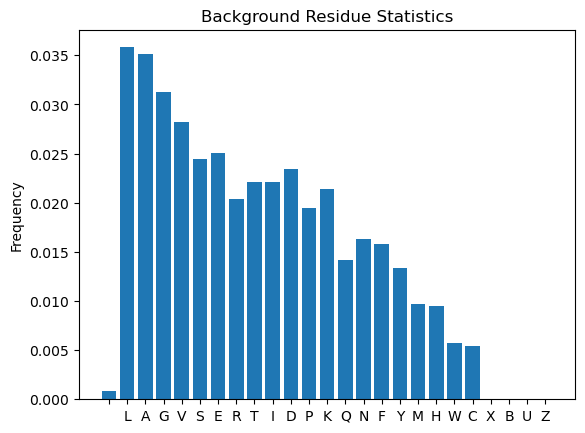

In [28]:
print(bert_distr.mean(dim=(0, 1)))
plt.bar(vocab, bert_distr.mean(dim=(0, 1)), label=vocab)
plt.title('Background Residue Statistics')
plt.ylabel('Frequency')
plt.show()

In [24]:
si, ei = 4, 29
background_distr = torch.zeros(ei-si)
for bi, seq in zip(range(bert_distr.shape[0]), enzyme_df['Sequence']):
    background_distr += bert_distr[bi, 1:len(seq)+1, si:ei].mean(dim=0)
background_distr /= bert_distr.shape[0]

In [28]:
print(background_distr.sum())

tensor(0.9927)


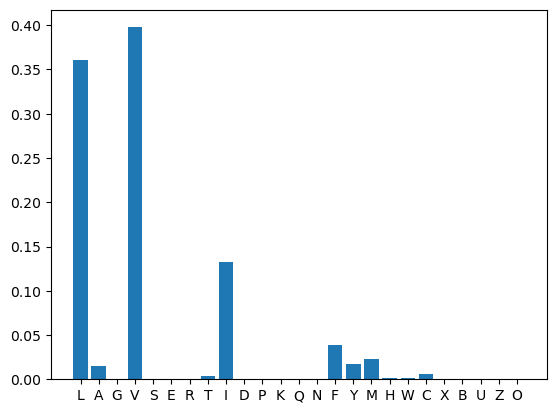

In [46]:
import matplotlib.pyplot as plt
import numpy as np
plt.bar(vocab[si:ei], bert_distr[0, 11, si:ei])
plt.show()

In [7]:
print(tokenizer.get_vocab())
[4:29]

{'<cls>': 0, '<pad>': 1, '<eos>': 2, '<unk>': 3, 'L': 4, 'A': 5, 'G': 6, 'V': 7, 'S': 8, 'E': 9, 'R': 10, 'T': 11, 'I': 12, 'D': 13, 'P': 14, 'K': 15, 'Q': 16, 'N': 17, 'F': 18, 'Y': 19, 'M': 20, 'H': 21, 'W': 22, 'C': 23, 'X': 24, 'B': 25, 'U': 26, 'Z': 27, 'O': 28, '.': 29, '-': 30, '<null_1>': 31, '<mask>': 32}


In [43]:
bert_re = (bert_distr*torch.log(bert_distr) - torch.log(background_distr)).sum(dim=-1)

In [10]:
# attr_dict = {'attributions_ig': attributions_ig, 'attributions_lact': attributions_lact, 'attributions_lfa': attributions_lfa}
import pickle
with open('../../data/enzyme_attributions.pkl', 'rb') as f:
    attr_dict = pickle.load(f)

In [11]:
attributions_ig = attr_dict['attributions_ig']
sum_attributions_ig = attributions_ig.sum(dim=2)
magn_attributions_ig = attributions_ig.norm(dim=2)

attributions_lact = attr_dict['attributions_lact']
sum_attributions_lact = attributions_lact.sum(dim=2)
magn_attributions_lact = attributions_lact.norm(dim=2)

attributions_lfa = attr_dict['attributions_lfa']

attributions_bert = bert_attribution.to('cpu')
for attr in [sum_attributions_ig, magn_attributions_ig, sum_attributions_lact, magn_attributions_lact, attributions_lfa, attributions_bert]:
    attr /= torch.norm(attr)

In [12]:
for attr in [sum_attributions_ig, magn_attributions_ig, sum_attributions_lact, magn_attributions_lact, attributions_lfa, attributions_bert]:
    print(attr.device)

cpu
cpu
cpu
cpu
cpu
cpu


In [16]:
r = next(iter(enzyme_iterator()))
text = r['seq']
tokens, mask = torch.tensor(r['seq_ind']).to('cpu'), torch.BoolTensor(r['mask']).to('cpu')
print(r['annot_ind'])
from IPython.display import display, HTML
from captum.attr._utils.visualization import format_word_importances

true_importances = torch.zeros_like(tokens)
true_importances[0, r['annot_ind']] = 1
dom = format_word_importances(text[150:250], true_importances[151:251])
html = HTML("".join(dom))
display(html)

[162, 191, 217, 242, 266, 294]


In [ ]:
from IPython.display import display, HTML
from captum.attr._utils.visualization import format_word_importances
text = next(iter(enzyme_df['Sequence']))[:50]
inputs = tokenizer.batch_encode_plus([text], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
tokens, mask =  torch.tensor(inputs['input_ids']).to(device), torch.BoolTensor(inputs['attention_mask']).to(device)
seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :51], mask[:, :51], tokenizer.mask_token_id, residue_coverage=residue_coverage)

dom = format_word_importances(text, torch.zeros(len(text)))
html = HTML("".join(dom))
display(html)

masking = -0.5*(seq_batch == tokenizer.mask_token_id).cpu()
dom = [format_word_importances(text, 0*masking[i]) for i in range(seq_batch.shape[0])]
html = HTML("".join(dom))
display(html)

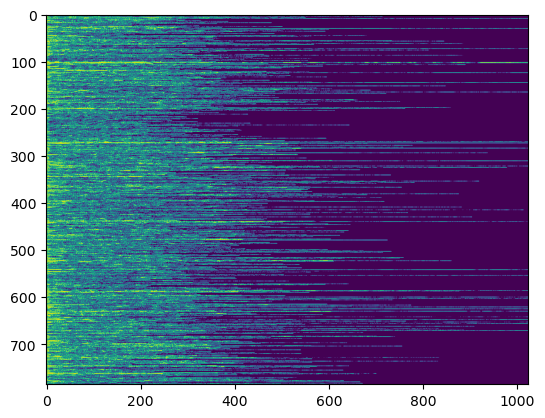

In [29]:
import matplotlib.pyplot as plt
plt.imshow(bert_attr)
plt.show()

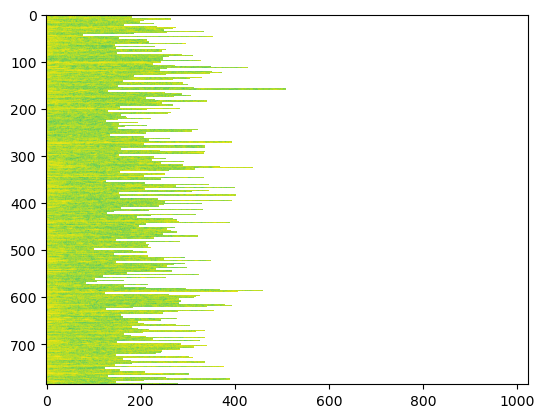

In [45]:
plt.imshow(bert_re)
plt.show()

In [43]:
def mean_reciprocal_rank(token_attribution, conserved_tokens):
    token_attribution =  token_attribution - 1e5*(token_attribution == 0) #Ignore padding
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        token_ranks = attribution_ranks[i, token_ind]
        ttr += torch.divide(1, token_ranks+1).sum()
        tct += token_ranks.shape[0]
    return ttr / tct

def mean_percent_rank(token_attribution, seq_len, conserved_tokens):
    token_mask = torch.tile(torch.arange(0, 1024).reshape(1, -1), (token_attribution.shape[0], 1))
    token_mask[:, 0] += 1024
    token_mask = token_mask < seq_len.reshape(-1, 1)
    token_attribution =  token_attribution.clone() - 1e5*(~token_mask)
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    attribution_percent_rank = attribution_ranks / seq_len.reshape(-1, 1)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        # print(token_ind)
        token_ranks = attribution_percent_rank[i, token_ind]
        # print(token_ranks)
        ttr += token_ranks.sum()
        tct += token_ranks.shape[0]
    return ttr / tct

def max_percent_rank(token_attribution, seq_len, conserved_tokens):
    token_mask = torch.tile(torch.arange(0, 1024).reshape(1, -1), (token_attribution.shape[0], 1))
    token_mask[:, 0] += 1024
    token_mask = token_mask < seq_len.reshape(-1, 1)
    token_attribution =  token_attribution.clone() - 1e5*(~token_mask)
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    attribution_percent_rank = attribution_ranks / seq_len.reshape(-1, 1)
    ttmax = 0
    ttmin = 0
    for i, token_ind in enumerate(conserved_tokens):
        if(len(token_ind)> 0):
            token_ranks = attribution_percent_rank[i, token_ind]
            ttmin += token_ranks.min()
            ttmax += token_ranks.max()
    return ttmin / token_attribution.shape[0], ttmax / token_attribution.shape[0]

mrr = mean_reciprocal_rank(-bert_attr, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(-bert_attr, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
maxpr = max_percent_rank(-bert_attr, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))

print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}, Max-Percentage Rank {maxpr}')

mrr = mean_reciprocal_rank(bert_re, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(bert_re, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

Mean-Reciprocal Rank 0.13240660727024078, Mean-Percentage Rank 0.1901424527168274, Max-Percentage Rank 0.0629032626748085


NameError: name 'bert_re' is not defined

In [52]:
from IPython.display import display, HTML
from captum.attr._utils.visualization import format_word_importances
text = next(iter(enzyme_df['Sequence']))[:50]
inputs = tokenizer.batch_encode_plus([text], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
tokens, mask =  torch.tensor(inputs['input_ids']).to(device), torch.BoolTensor(inputs['attention_mask']).to(device)
seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :51], mask[:, :51], tokenizer.mask_token_id, residue_coverage=residue_coverage)

dom = format_word_importances(text, torch.zeros(len(text)))
html = HTML("".join(dom))
display(html)

masking = -0.5*(seq_batch == tokenizer.mask_token_id).cpu()
dom = [format_word_importances(text, 0*masking[i]) for i in range(seq_batch.shape[0])]
html = HTML("".join(dom))
display(html)

In [36]:
print((seq_batch == tokenizer.mask_token_id).sum(dim=0))

tensor([0, 2, 2,  ..., 0, 0, 0], device='cuda:1')


In [1]:
from transformers import AutoModelForMaskedLM
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, AutoModelForSeq2SeqLM, AutoConfig
import torch
device = torch.device('cuda:1')

tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
config = AutoConfig.from_pretrained('facebook/esm2_t33_650M_UR50D')
model = AutoModelForMaskedLM.from_pretrained('facebook/esm2_t33_650M_UR50D').to(device)
model.eval()
print("Loaded BERT Model")

import pandas as pd
enzyme_df= pd.read_csv('~/GO_interp/data/enzyme_dataset_seq.csv')
enzyme_df= enzyme_df[~enzyme_df['Sequence'].isna()]
enzyme_go_terms = [gt.split("'")[1] for gt in enzyme_df['GOTerm']]
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
enzyme_df['GOTerm'] = enzyme_go_terms
enzyme_df= enzyme_df[enzyme_df['GOTerm'].isin(term_ind_map)]
enzyme_term_index = [term_ind_map[t] for t in enzyme_df['GOTerm']]
enzyme_df['GOTermIndex'] = enzyme_term_index
annotated_indices = [list(filter(lambda x: x < min(1024, len(seq)), map(int, x[1:-1].split(',')))) for x, seq in zip(enzyme_df['AnnotatedIndices'], enzyme_df['Sequence'])]
enzyme_df['AnnotatedIndices'] = annotated_indices

import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t33_650M_UR50D')
def enzyme_iterator():
     for i, pid, annot_ind, enzyme_cls, goterm, seq, go_ind in enzyme_df.itertuples():
          # print(pid, annot_ind, enzyme_cls, goterm, seq, go_ind)
          inputs = tokenizer.batch_encode_plus([seq], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
          yield {'prot_id': pid, 'annot_ind': annot_ind, 'go_ind': go_ind, 'seq': seq, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask']}

def mask_seq(seq_ind, attention_mask, mask_token, residue_coverage=6, mut_per=0.15):
    device = seq_ind.device
    seq_len = attention_mask.sum()-1
    mut_count = torch.floor(seq_len*mut_per).int().item()
    total_muts = (torch.floor(seq_len*residue_coverage/mut_count)*mut_count).int().item()

    mut_inds = (torch.randperm(total_muts).reshape(-1, mut_count).to(device) % seq_len) + 1
    batch_inds = torch.tile(torch.arange(0, mut_inds.shape[0]).reshape((-1, 1)), (1, mut_count))
    mut_inds, batch_inds = mut_inds.to(device), batch_inds.to(device)

    batch = torch.tile(seq_ind, (mut_inds.shape[0], 1))
    batch[batch_inds, mut_inds] = mask_token
    return batch, batch_inds, mut_inds


/home/andrew/anaconda3/envs/gointerp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded BERT Model


In [3]:

bert_distr_l = []
with torch.no_grad():
    for i, r in enumerate(enzyme_iterator()):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        residue_coverage = 6
        seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :], mask[:, :], tokenizer.mask_token_id, residue_coverage=residue_coverage)
        print(seq_batch.shape)
        bert_pred = model(seq_batch, torch.tile(mask, (seq_batch.shape[0], 1)))
        mut_distr = torch.softmax(bert_pred.logits, dim=2)
        N, L, T = bert_pred.logits.shape
        bert_distr = torch.zeros(L, T, device=device)
        for bi, ti in zip(batch_inds.flatten(), mut_inds.flatten()):
            bert_distr[ti, :] += mut_distr[bi, ti, :]
        bert_distr /= residue_coverage
        bert_distr_l.append(bert_distr.cpu())
        if(i % 3 == 0):
            print(f"{100*i/len(enzyme_go_terms)}")


torch.Size([40, 1024])
0.0
torch.Size([40, 1024])
torch.Size([40, 1024])


KeyboardInterrupt: 